# Example-01: Model setup

In [1]:
# Import

import numpy
import pandas
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.statistics import mean, variance
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

False


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Model configuration is stored in a yaml format (python dictionary) with data for each location (a point of interest)
# Model can be specified by CS twiss parameters (and corresponding errors) at locations and phase advances between locations (uncoupled model)
# Or model can be specified by normalization matrices (and corresponding errors) at the locations and phase advances between locations (coupled model)

In [4]:
# Uncoupled model is specified by CS twiss parameters and phase advances (from start to location) has the following format:

# DEFAULT CONFIGURATION FILE (UNCOUPLED MODEL FROM TWISS)
# NOTE, HEAD AND TAIL VIRTUAL LOCATIONS SHOULD ALWAYS PRESENT

# LOCATION RECORD
# <NAME>: {TYPE:<TYPE>, FLAG:<FLAG>, JOIN:<JOIN>, RISE:<RISE>, TIME:<TIME>, AX:<AX>, BX:<BX>, FX:<FX>, AY:<AY>, BX:<BY>, FY:<FY>, SIGMA_AX:<SIGMA_AX>, SIGMA_BX:<SIGMA_BX>, SIGMA_FX:<SIGMA_FX>, SIGMA_AY:<SIGMA_AY>, SIGMA_BY:<SIGMA_BY>, SIGMA_FY:<SIGMA_FY>}
# <NAME>:
#   LOCATION NAME
#   HEAD & TAIL ARE SPECIAL VIRTUAL LOCATIONS
# <TYPE>:
#   LOCATION TYPE (VIRTUAL OR MONITOR)
#   MONITOR TYPE SHOULD BE USED FOR LOCATIONS WHERE TBT DATA IS AVALIBLE
#   OTHER LOCATIONS WHERE TBT DATA IS NOT AVALIBLE DIRECTRY SHOULD BE DEFINED AS VIRTUAL
#   FREQUENCY AND OTHER PARAMETERS INFERRED FROM TBT DATA ARE NOT COMPUTED FOR VIRTUAL LOCATIONS
#   IF BPM IS OFF, TYPE IS CHANGED TO VIRTUAL
#   IF BPM IS FLAGGED (E.G. ANOMALY OR SHYNCHRONIZATION ERROR), TYPE IS CHANGED TO VIRTUAL
# <FLAG>:
#   FLAG TO COMPUTE OPTICS (0 OR 1)
# <JOIN>:
#   FLAG TO USE IN MIXED DATA COMPUTAION
# <RISE>:
#   LOCATION RISE
#   STARTING TURN FOR MONITOR LOCATION
# <TIME>:
#   PHYSICAL LOCATION
#   NOTE, ORDERING IS CHECKED BY PHYSICAL LOCATION
# <AX>, <BX>, <FX>, <AY>, <BY>, <FY>
#   UNCOUPLED TWISS PARAMETERS
#   NOTE, PHASE ADVANCE IS DEFIEND FROM HEAD TO LOCATION
# <SIGMA_AX>, <SIGMA_BX>, <SIGMA_FX>, <SIGMA_AY>, <SIGMA_BY>, <SIGMA_FY>
#   MODEL TWISS ERROR AT THE LOCATION AND PHASE ADVANCE ERROR FROM GIVEN LOCATION TO THE NEXT ONE

# HEAD            :  {TYPE: VIRTUAL         , FLAG:  0, JOIN:  0, RISE: -1, TIME:   0.0000000000000000E+00, AX:  -6.7832172200684859E-01, BX:   7.4674609407469461E+00, FX:   0.0000000000000000E+00, AY:   6.5444027545037686E-01, BY:   1.5854388146461160E+01, FY:   0.0000000000000000E+00, SIGMA_AX:   0.0000000000000000E+00, SIGMA_BX:   0.0000000000000000E+00, SIGMA_FX:   0.0000000000000000E+00, SIGMA_AY:   0.0000000000000000E+00, SIGMA_BY:   0.0000000000000000E+00, SIGMA_FY:   0.0000000000000000E+00}
# STP2            :  {TYPE: MONITOR         , FLAG:  1, JOIN:  1, RISE:  8, TIME:   0.0000000000000000E+00, AX:  -6.7832172200684859E-01, BX:   7.4674609407469461E+00, FX:   0.0000000000000000E+00, AY:   6.5444027545037686E-01, BY:   1.5854388146461160E+01, FY:   0.0000000000000000E+00, SIGMA_AX:   0.0000000000000000E+00, SIGMA_BX:   0.0000000000000000E+00, SIGMA_FX:   0.0000000000000000E+00, SIGMA_AY:   0.0000000000000000E+00, SIGMA_BY:   0.0000000000000000E+00, SIGMA_FY:   0.0000000000000000E+00}
# ...
# TAIL            :  {TYPE: VIRTUAL         , FLAG:  0, JOIN:  0, RISE: -1, TIME:   3.6607501559999957E+02, AX:  -6.7832172200673979E-01, BX:   7.4674609407466637E+00, FX:   5.3638818455096327E+01, AY:   6.5444027545039363E-01, BY:   1.5854388146461030E+01, FY:   4.7606279051923941E+01, SIGMA_AX:   0.0000000000000000E+00, SIGMA_BX:   0.0000000000000000E+00, SIGMA_FX:   0.0000000000000000E+00, SIGMA_AY:   0.0000000000000000E+00, SIGMA_BY:   0.0000000000000000E+00, SIGMA_FY:   0.0000000000000000E+00}

In [5]:
# Coupled model specified by normalization matrices and phase advances (from start to location) has the following format

# DEFAULT CONFIGURATION FILE (COUPLED MODEL FROM NORMAL)
# NOTE, HEAD AND TAIL VIRTUAL LOCATIONS SHOULD ALWAYS PRESENT

# LOCATION RECORD
# <NAME>: {TYPE:<TYPE>, FLAG:<FLAG>, JOIN:<JOIN>, RISE:<RISE>, TIME:<TIME>, ..., NIJ:<NIJ>, ..., FX:<FX>, FY:<FY>, ..., SIGMA_NIJ:<SIGMA_NIJ>, ... , SIGMA_FX:<SIGMA_FX>, SIGMA_FY:<SIGMA_FY>}
# <NAME>:
#   LOCATION NAME
#   HEAD & TAIL ARE SPECIAL VIRTUAL LOCATIONS
# <TYPE>:
#   LOCATION TYPE (VIRTUAL OR MONITOR)
#   MONITOR TYPE SHOULD BE USED FOR LOCATIONS WHERE TBT DATA IS AVALIBLE
#   OTHER LOCATIONS WHERE TBT DATA IS NOT AVALIBLE DIRECTRY SHOULD BE DEFINED AS VIRTUAL
#   FREQUENCY AND OTHER PARAMETERS INFERRED FROM TBT DATA ARE NOT COMPUTED FOR VIRTUAL LOCATIONS
#   IF BPM IS OFF, TYPE IS CHANGED TO VIRTUAL
#   IF BPM IS FLAGGED (E.G. ANOMALY OR SHYNCHRONIZATION ERROR), TYPE IS CHANGED TO VIRTUAL
# <FLAG>:
#   FLAG TO COMPUTE OPTICS (0 OR 1)
# <JOIN>:
#   FLAG TO USE IN MIXED DATA COMPUTAION
# <RISE>:
#   LOCATION RISE
#   STARTING TURN FOR MONITOR LOCATION
# <TIME>:
#   PHYSICAL LOCATION
#   NOTE, ORDERING IS CHECKED BY PHYSICAL LOCATION
# <NIJ>:
#   NORMALIZATION MATRIX IJ ELEMENT
# <FX>, <FY>
#   PHASE ADVANCE
#   NOTE, PHASE ADVANCE IS DEFIEND FROM HEAD TO LOCATION
# <SIGMA_NIJ>
#   MODEL NORMALIZATION MATRIX IJ ELEMENT ERROR
# <SIGMA_FX>, <SIGMA_FY>
#   PHASE ADVANCE ERROR FROM GIVEN LOCATION TO THE NEXT ONE

# HEAD            :  {TYPE: VIRTUAL         , FLAG:  0, JOIN:  0, RISE: -1, TIME:   0.0000000000000000E+00, N00:   2.7326655376659064E+00, N01:   0.0000000000000000E+00, N02:   0.0000000000000000E+00, N03:   0.0000000000000000E+00, N10:   2.4822712939331223E-01, N11:   3.6594306409490018E-01, N12:   0.0000000000000000E+00, N13:   0.0000000000000000E+00, N20:   0.0000000000000000E+00, N21:   0.0000000000000000E+00, N22:   3.9817569170481910E+00, N23:   0.0000000000000000E+00, N30:   0.0000000000000000E+00, N31:   0.0000000000000000E+00, N32:  -1.6435967566185433E-01, N33:   2.5114541666730716E-01, FX:   0.0000000000000000E+00, FY:   0.0000000000000000E+00, SIGMA_N00:   0.0000000000000000E+00, SIGMA_N01:   0.0000000000000000E+00, SIGMA_N02:   0.0000000000000000E+00, SIGMA_N03:   0.0000000000000000E+00, SIGMA_N10:   0.0000000000000000E+00, SIGMA_N11:   0.0000000000000000E+00, SIGMA_N12:   0.0000000000000000E+00, SIGMA_N13:   0.0000000000000000E+00, SIGMA_N20:   0.0000000000000000E+00, SIGMA_N21:   0.0000000000000000E+00, SIGMA_N22:   0.0000000000000000E+00, SIGMA_N23:   0.0000000000000000E+00, SIGMA_N30:   0.0000000000000000E+00, SIGMA_N31:   0.0000000000000000E+00, SIGMA_N32:   0.0000000000000000E+00, SIGMA_N33:   0.0000000000000000E+00, SIGMA_FX:   0.0000000000000000E+00, SIGMA_FY:   0.0000000000000000E+00}
# STP2            :  {TYPE: MONITOR         , FLAG:  1, JOIN:  1, RISE:  8, TIME:   0.0000000000000000E+00, N00:   2.7326655376659064E+00, N01:   0.0000000000000000E+00, N02:   0.0000000000000000E+00, N03:   0.0000000000000000E+00, N10:   2.4822712939331223E-01, N11:   3.6594306409490018E-01, N12:   0.0000000000000000E+00, N13:   0.0000000000000000E+00, N20:   0.0000000000000000E+00, N21:   0.0000000000000000E+00, N22:   3.9817569170481910E+00, N23:   0.0000000000000000E+00, N30:   0.0000000000000000E+00, N31:   0.0000000000000000E+00, N32:  -1.6435967566185433E-01, N33:   2.5114541666730716E-01, FX:   0.0000000000000000E+00, FY:   0.0000000000000000E+00, SIGMA_N00:   0.0000000000000000E+00, SIGMA_N01:   0.0000000000000000E+00, SIGMA_N02:   0.0000000000000000E+00, SIGMA_N03:   0.0000000000000000E+00, SIGMA_N10:   0.0000000000000000E+00, SIGMA_N11:   0.0000000000000000E+00, SIGMA_N12:   0.0000000000000000E+00, SIGMA_N13:   0.0000000000000000E+00, SIGMA_N20:   0.0000000000000000E+00, SIGMA_N21:   0.0000000000000000E+00, SIGMA_N22:   0.0000000000000000E+00, SIGMA_N23:   0.0000000000000000E+00, SIGMA_N30:   0.0000000000000000E+00, SIGMA_N31:   0.0000000000000000E+00, SIGMA_N32:   0.0000000000000000E+00, SIGMA_N33:   0.0000000000000000E+00, SIGMA_FX:   0.0000000000000000E+00, SIGMA_FY:   0.0000000000000000E+00}
# ...
# TAIL            :  {TYPE: VIRTUAL         , FLAG:  0, JOIN:  0, RISE: -1, TIME:   3.6607501559999957E+02, N00:   2.7326655376658477E+00, N01:  -2.2204460492503131E-16, N02:   0.0000000000000000E+00, N03:   0.0000000000000000E+00, N10:   2.4822712939327973E-01, N11:   3.6594306409490629E-01, N12:   0.0000000000000000E+00, N13:   0.0000000000000000E+00, N20:   0.0000000000000000E+00, N21:   0.0000000000000000E+00, N22:   3.9817569170481679E+00, N23:  -2.2204460492503131E-16, N30:   0.0000000000000000E+00, N31:   0.0000000000000000E+00, N32:  -1.6435967566185916E-01, N33:   2.5114541666730861E-01, FX:   5.3638818455096327E+01, FY:   4.7606279051923941E+01, SIGMA_N00:   0.0000000000000000E+00, SIGMA_N01:   0.0000000000000000E+00, SIGMA_N02:   0.0000000000000000E+00, SIGMA_N03:   0.0000000000000000E+00, SIGMA_N10:   0.0000000000000000E+00, SIGMA_N11:   0.0000000000000000E+00, SIGMA_N12:   0.0000000000000000E+00, SIGMA_N13:   0.0000000000000000E+00, SIGMA_N20:   0.0000000000000000E+00, SIGMA_N21:   0.0000000000000000E+00, SIGMA_N22:   0.0000000000000000E+00, SIGMA_N23:   0.0000000000000000E+00, SIGMA_N30:   0.0000000000000000E+00, SIGMA_N31:   0.0000000000000000E+00, SIGMA_N32:   0.0000000000000000E+00, SIGMA_N33:   0.0000000000000000E+00, SIGMA_FX:   0.0000000000000000E+00, SIGMA_FY:   0.0000000000000000E+00}

In [6]:
# Set uncoupled Model instance
# All configuration is saved in data_frame attribute

model = Model(path='../config_uncoupled.yaml', model='uncoupled', dtype=dtype, device=device)
model.data_frame

,HEAD,STP2,IV4P,STP4,SRP1,SRP2,SRP3,SRP4,SRP5,SRP6,...,NRP4,NRP3,NRP2,NRP1,NTP4,IV4E,NTP2,NTP0,STP0,TAIL
TYPE,VIRTUAL,MONITOR,VIRTUAL,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,...,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,VIRTUAL,MONITOR,MONITOR,MONITOR,VIRTUAL
FLAG,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0
JOIN,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0
RISE,-1,8,-1,8,8,8,8,8,8,8,...,9,9,9,9,9,-1,9,9,9,-1
TIME,0.0,0.0,4.1535,6.667,10.190565,17.337624,24.484683,31.631742,38.778801,45.92586,...,314.367774,321.514833,328.661892,335.808951,339.332516,341.846016,345.999516,353.307016,358.767516,366.075016
AX,-0.678322,-0.678322,1.955065,0.382216,-0.801359,-0.720007,-0.769987,-0.788485,-0.715242,-0.788853,...,0.788485,0.769987,0.720007,0.801359,-0.382216,-1.955065,0.678322,0.187567,-0.187567,-0.678322
BX,7.467461,7.467461,14.238343,3.121346,4.735711,4.560311,4.48402,4.755363,4.490419,4.552264,...,4.755363,4.48402,4.560311,4.735711,3.121346,14.238343,7.467461,15.068229,15.068229,7.467461
FX,0.0,0.0,0.385863,0.837521,1.965122,3.064451,4.221361,5.333373,6.443944,7.601242,...,45.781099,46.893111,48.050022,49.14935,50.276951,50.72861,51.114472,52.191233,52.562058,53.638818
AY,0.65444,0.65444,-2.759872,3.092008,1.839816,1.839551,1.84704,1.847097,1.839606,1.839758,...,-1.847097,-1.84704,-1.839551,-1.839816,-3.092008,2.759872,-0.65444,0.954725,-0.954725,0.65444
BY,15.854388,15.854388,13.855747,30.432785,13.261256,13.282406,13.324616,13.302293,13.260703,13.284183,...,13.302293,13.324616,13.282406,13.261256,30.432785,13.855747,15.854388,5.466362,5.466362,15.854388


In [7]:
# Main attributes (on initialization, note, additional attributes are set by instance methods)

#     _epsilon: float
#         float epsilon
#     _head: str
#         head location name
#     _tail: str
#         tail location name
#     _virtual: str
#         virtual type
#     _monitor: str
#         monitor type
#     dtype: torch.dtype
#         torch data type
#     device: torch.device
#         torch device
#     path: str
#         path to yaml config file
#     limit: int
#         maximum range limit
#     error: bool
#         flag to compute model advance errors
#     model: str
#         model type ('uncoupled' or 'coumpled')
#     dict: dict
#         yaml file as dict
#     data_frame: pandas.DataFrame
#         yaml config file as data frame
#     size: int
#         number of locations
#     name: list
#         location names
#     kind: list
#         location kinds (expected kinds _virtual or _monitor)
#     flag: torch.Tensor
#         flags
#     join: list
#         join flags
#     rise: list
#         starting turn
#     time: torch.Tensor
#         position
#     length: torch.Tensor
#         total length
#     monitor_index: list
#         list of monitor location indices
#     monitor_count: int
#         number of monitor locations
#     virtual_index: list
#         list of virtual location indices
#     virtual_count: int
#         number of virtual locations
#     monitor_name: list
#         list of monitor location names
#     virtual_name: list
#         list of virtual location names
#     ax, bx, ay, by: torch.Tensor
#         CS twiss parameters
#     sigma_ax, sigma_bx, sigma_ay, sigma_by: torch.Tensor
#         CS twiss parameters errors
#     normal: torch.Tensor
#         normalization matrices
#     sigma_normal: torch.Tensor
#         normalization matrices error
#     fx, fy: torch.Tensor
#         x & y phase advance from start to each location
#     sigma_fx, sigma_fy: torch.Tensor
#         x & y phase advance error from start to each location
#     mux, muy: torch.Tensor
#         x & y total phase advance
#     sigma_mux, sigma_muy:
#         x & y total phase advance errors
#     nux, nuy: torch.Tensor
#         x & y tune
#     sigma_nux, sigma_nuy: torch.Tensor
#         x & y tune error
#     phase_x, phase_y: torch.Tensor
#         x & y phase advance between adjacent locations
#     sigma_x, sigma_y: torch.Tensor
#         x & y phase advance errors between adjacent locations
#     monitor_phase_x, monitor_phase_y: torch.Tensor
#         x & y phase advance between adjacent monitor locations
#     monitor_sigma_x, monitor_sigma_y: torch.Tensor
#         x & y phase advance errors between adjacent monitor locations
#     count: torch.Tensor
#         (limit != None) ange limit endpoints [1, 6, 15, 28, 45, 66, 91, 120, ...]
#     table: torch.Tensor
#         (limit != None) index table
#     combo: torch.Tensor
#         (limit != None) index combinations [..., [..., [[i, j], [i, k]], ...], ...]
#     index: torch.Tensor
#         (limit != None) index combimations mod number of locations
#     fx_ij: torch.Tensor
#         (limit != None) x model advance i to j
#     fx_ik: torch.Tensor
#         (limit != None) x model advance i to k
#     sigma_fx_ij: torch.Tensor
#         (limit != None) x model advance error i to j
#     sigma_fx_ik: torch.Tensor
#         (limit != None) x model advance error i to k
#     fy_ij: torch.Tensor
#         (limit != None) y model advance i to j
#     fy_ik: torch.Tensor
#         (limit != None) y model advance i to k
#     sigma_fy_ij: torch.Tensor
#         (limit != None) y model advance error i to j
#     sigma_fy_ik: torch.Tensor
#         (limit != None) y model advance error i to k
#     error_kn, error_ks: torch.Tensor
#         (make_error) kn & ks quadrupole amplitudes
#     error_length: torch.Tensor
#         (make_error) quadrupole length
#     error_x & error_y: torch.Tensor
#         (make_error) x & y corrector angles
#     error_matrix: torch.Tensor
#         (make_error) quadrupole matrices
#     error_vector: torch.Tensor
#         (make_error) corrector vectors
#     orbit: torch.Tensor
#         (make_transport) closed orbit
#     transport: torch.Tensor
#         (make_transport)trasport matrces from start to each location
#     turn: torch.Tensor
#         (make_transport)one-turn matrix at start
#     is_stable: torch.Tensor
#         (make_twiss) stable flag
#     out_wolski: torch.Tensor
#         (make_twiss) Wolski twiss
#     out_cs:
#         (make_twiss) CS twiss
#     out_normal:
#         (make_twiss) normalization matrices
#     out_advance:
#         (make_twiss) phase advance between adjacent locations
#     out_tune:
#         (make_twiss) total tunes
#     out_tune_fractional:
#         (make_twiss) fractiona tunes

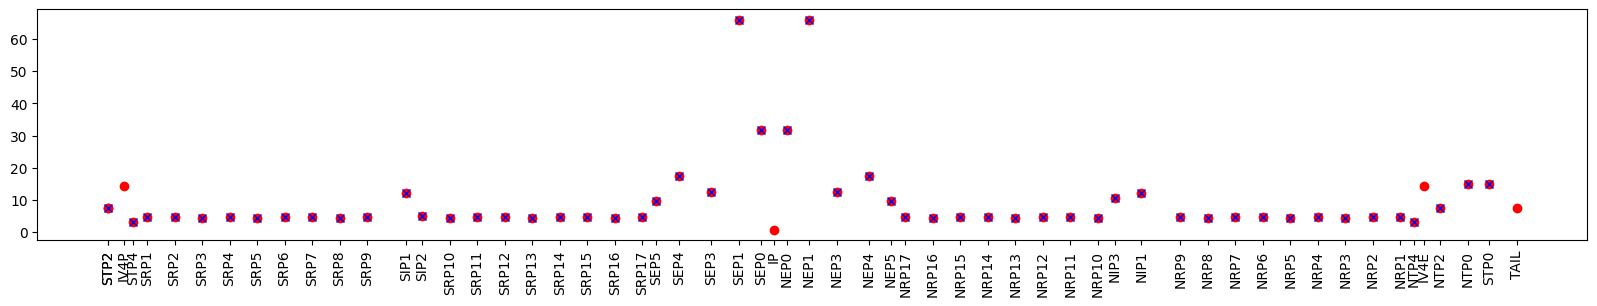

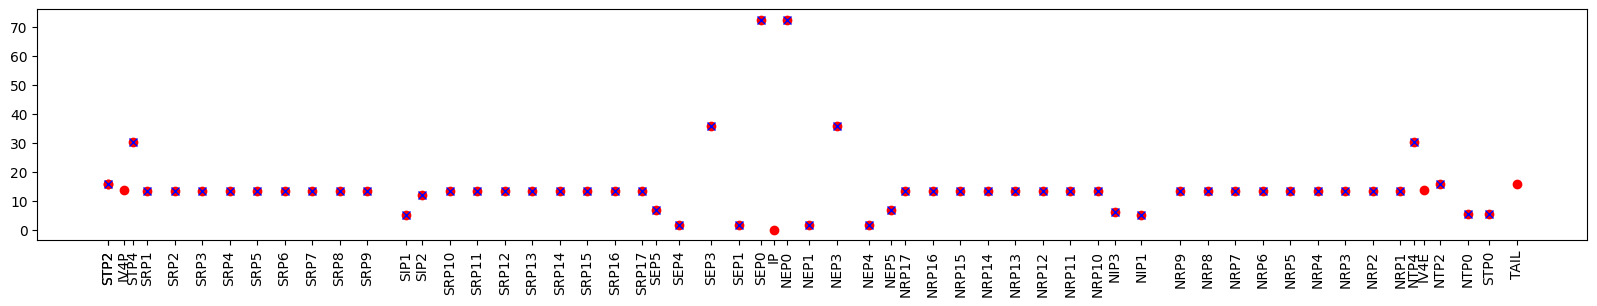

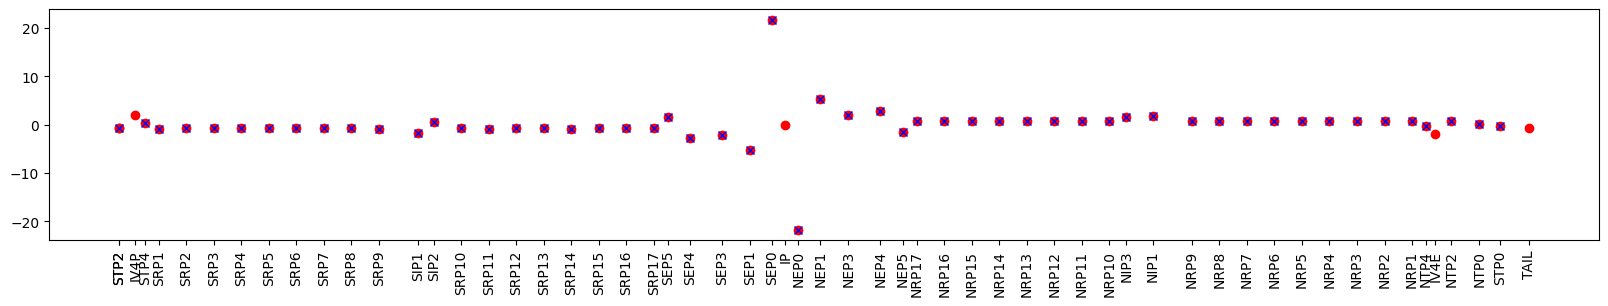

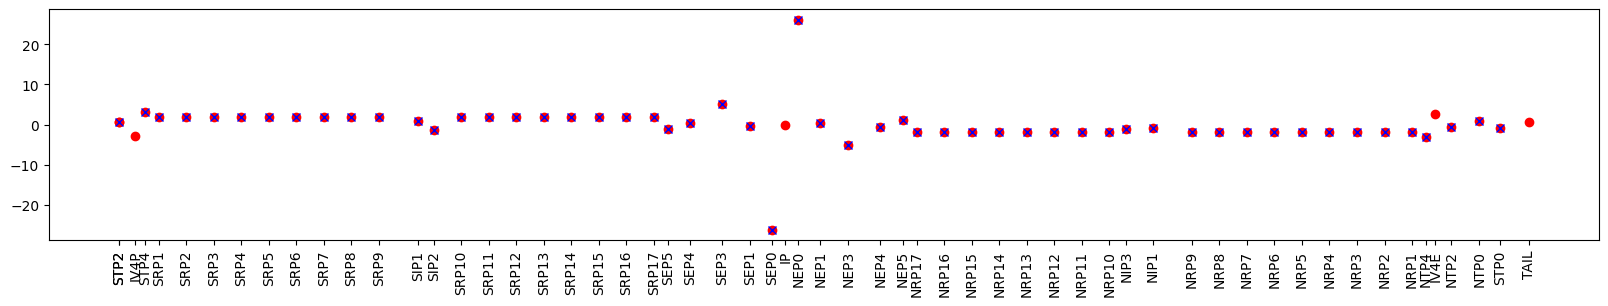

In [8]:
# Plot CS twiss parameters

# Note, 'HEAD' and 'STP2' locations are at the same position

# bx

plt.figure(figsize=(20, 3))
plt.errorbar(model.time.cpu().numpy(), model.bx.cpu().numpy(), yerr=model.sigma_bx.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.errorbar(model.time[model.monitor_index].cpu().numpy(), model.bx[model.monitor_index].cpu().numpy(), yerr=model.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', color='blue', marker='x')
plt.xticks(model.time.cpu().numpy(), model.name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

# by

plt.figure(figsize=(20, 3))
plt.errorbar(model.time.cpu().numpy(), model.by.cpu().numpy(), yerr=model.sigma_by.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.errorbar(model.time[model.monitor_index].cpu().numpy(), model.by[model.monitor_index].cpu().numpy(), yerr=model.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', color='blue', marker='x')
plt.xticks(model.time.cpu().numpy(), model.name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

# ax

plt.figure(figsize=(20, 3))
plt.errorbar(model.time.cpu().numpy(), model.ax.cpu().numpy(), yerr=model.sigma_ax.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.errorbar(model.time[model.monitor_index].cpu().numpy(), model.ax[model.monitor_index].cpu().numpy(), yerr=model.sigma_ax[model.monitor_index].cpu().numpy(), fmt=' ', color='blue', marker='x')
plt.xticks(model.time.cpu().numpy(), model.name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

# ay

plt.figure(figsize=(20, 3))
plt.errorbar(model.time.cpu().numpy(), model.ay.cpu().numpy(), yerr=model.sigma_ay.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.errorbar(model.time[model.monitor_index].cpu().numpy(), model.ay[model.monitor_index].cpu().numpy(), yerr=model.sigma_ay[model.monitor_index].cpu().numpy(), fmt=' ', color='blue', marker='x')
plt.xticks(model.time.cpu().numpy(), model.name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

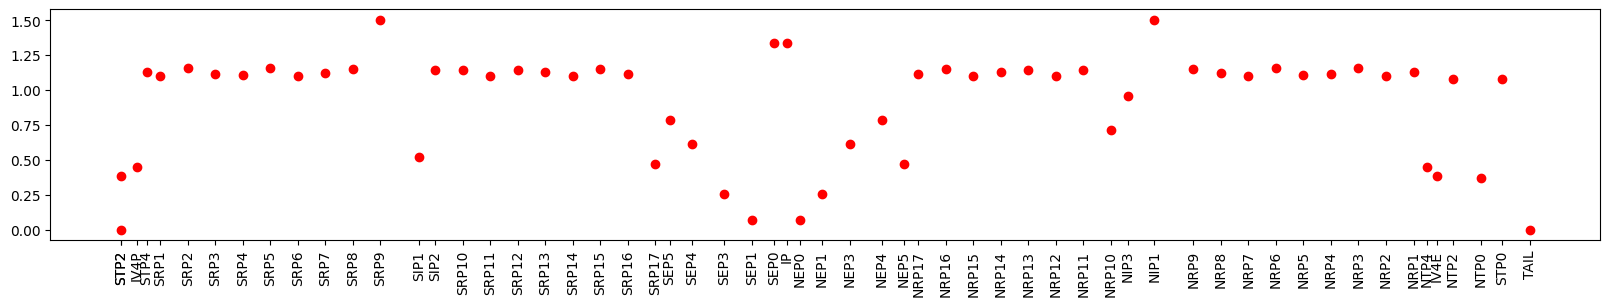

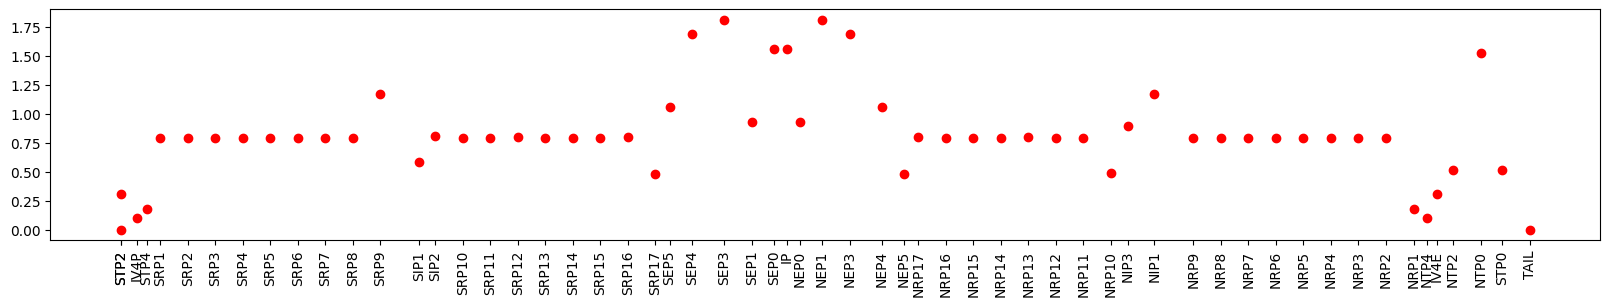

In [9]:
# Plot phase advance between locations

# phase_x

plt.figure(figsize=(20, 3))
plt.errorbar(model.time.cpu().numpy(), model.phase_x.cpu().numpy(), yerr=model.sigma_x.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.xticks(model.time.cpu().numpy(), model.name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

# phase_y

plt.figure(figsize=(20, 3))
plt.errorbar(model.time.cpu().numpy(), model.phase_y.cpu().numpy(), yerr=model.sigma_y.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.xticks(model.time.cpu().numpy(), model.name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

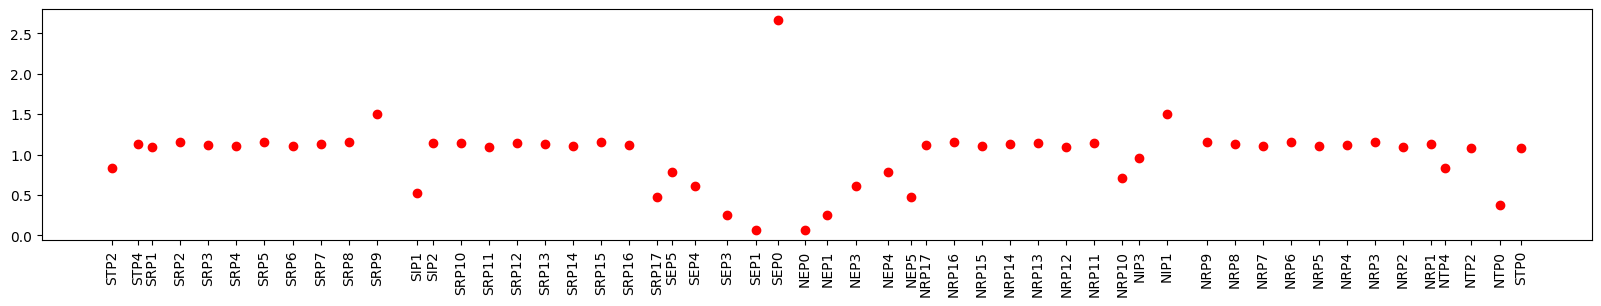

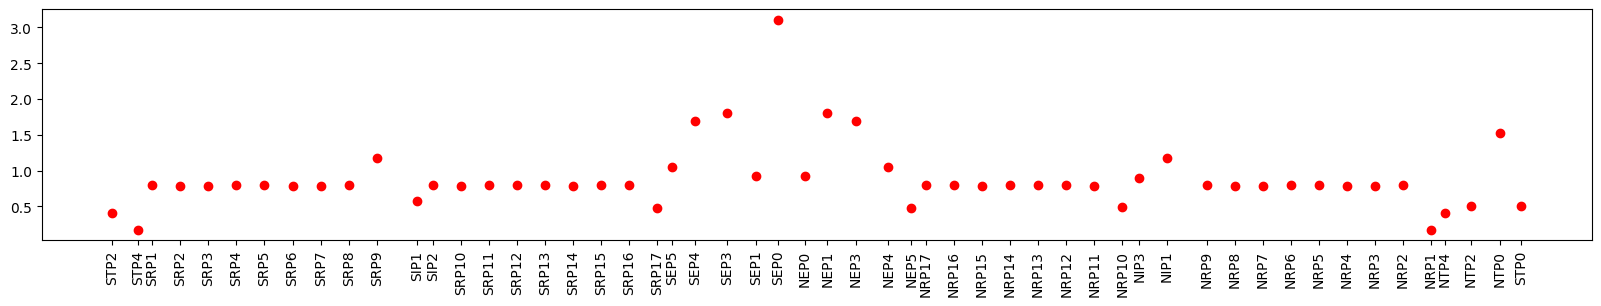

In [10]:
# Plot phase advance between monitor locations

# monitor_phase_x

plt.figure(figsize=(20, 3))
plt.errorbar(model.time[model.monitor_index].cpu().numpy(), model.monitor_phase_x.cpu().numpy(), yerr=model.monitor_sigma_x.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.xticks(model.time[model.monitor_index].cpu().numpy(), model.monitor_name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

# monitor_phase_y

plt.figure(figsize=(20, 3))
plt.errorbar(model.time[model.monitor_index].cpu().numpy(), model.monitor_phase_y.cpu().numpy(), yerr=model.monitor_sigma_y.cpu().numpy(), fmt=' ', color='red', marker='o')
plt.xticks(model.time[model.monitor_index].cpu().numpy(), model.monitor_name)
locs, lbls = plt.xticks()
plt.setp(lbls, rotation=90)
plt.show()

In [11]:
# Coupled model is specified by normalization matrices at locations and phase advances from start to location
# model.normal and model.sigma_normal

In [12]:
# Set coupled Model instance

model = Model(path='../config_coupled.yaml', model='coupled', dtype=dtype, device=device)
model.data_frame

,HEAD,STP2,IV4P,STP4,SRP1,SRP2,SRP3,SRP4,SRP5,SRP6,...,NRP4,NRP3,NRP2,NRP1,NTP4,IV4E,NTP2,NTP0,STP0,TAIL
TYPE,VIRTUAL,MONITOR,VIRTUAL,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,...,MONITOR,MONITOR,MONITOR,MONITOR,MONITOR,VIRTUAL,MONITOR,MONITOR,MONITOR,VIRTUAL
FLAG,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0
JOIN,0,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,0,1,1,1,0
RISE,-1,8,-1,8,8,8,8,8,8,8,...,9,9,9,9,9,-1,9,9,9,-1
TIME,0.0,0.0,4.1535,6.667,10.190565,17.337624,24.484683,31.631742,38.778801,45.92586,...,314.367774,321.514833,328.661892,335.808951,339.332516,341.846016,345.999516,353.307016,358.767516,366.075016
N00,2.732666,2.732666,3.773373,1.766733,2.176169,2.135489,2.11755,2.180679,2.119061,2.133603,...,2.180679,2.11755,2.135489,2.176169,1.766733,3.773373,2.732666,3.881782,3.881782,2.732666
N01,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,...,-0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0
N02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
N03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
N10,0.248227,0.248227,-0.518121,-0.21634,0.368243,0.337162,0.363621,0.361578,0.337528,0.369728,...,-0.361578,-0.363621,-0.337162,-0.368243,0.21634,0.518121,-0.248227,-0.04832,0.04832,0.248227
